# 🛍️ Amazon Reviews — Sentiment Analysis Pipeline
**Preprocessing → TF-IDF → Logistic Regression**

## 1. Imports & Setup

In [24]:
# data manipulation
import re
import numpy as np
import pandas as pd

# emoji handling
import emoji

# nltk
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)   # needed for lemmatizer

from nltk.corpus   import stopwords
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem     import PorterStemmer

# ml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.model_selection         import train_test_split
from sklearn.metrics                 import (accuracy_score,
                                             classification_report,
                                             confusion_matrix)

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful ✅')

All imports successful ✅


## 2. Load & Explore Data

In [25]:
data = pd.read_csv('data/amazon_reviews_dataset.csv')
print(f'Shape: {data.shape}')
data.head(4)

Shape: (600, 2)


,review_text,sentiment
0,This laptop is absolutely amazing 😍 I have been using it for about...,1
1,The headphones were delivered quickly but the sound quality is jus...,0
2,I bought this blender for making my morning smoothies and it blend...,1
3,These running shoes felt comfortable at first but they started fal...,0


In [26]:
print('Data types:')
print(data.dtypes)
print()
print('Null values:')
print(data.isnull().sum())

Data types:
review_text      str
sentiment      int64
dtype: object

Null values:
review_text    0
sentiment      0
dtype: int64


Label distribution:
sentiment
1    300
0    300
Name: count, dtype: int64


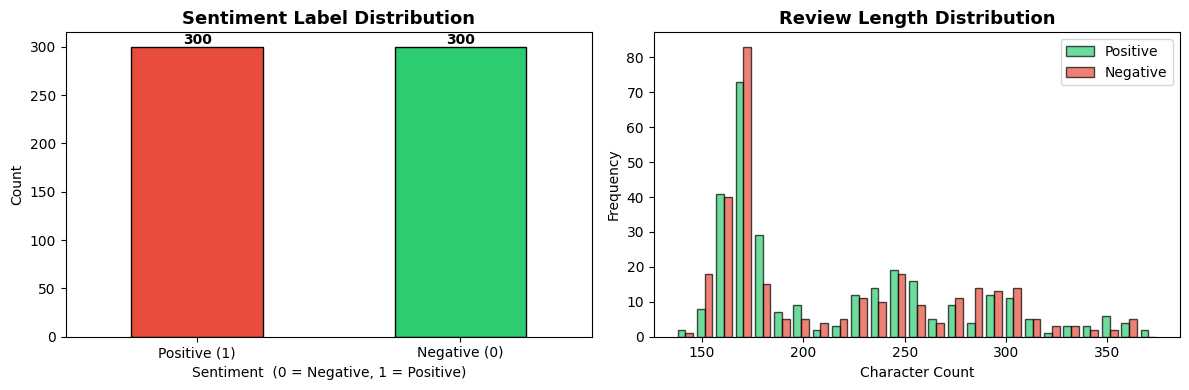

In [27]:
print('Label distribution:')
print(data['sentiment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# label bar chart
data['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Sentiment Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment  (0 = Negative, 1 = Positive)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive (1)', 'Negative (0)'], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 3,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# review length distribution
data['review_length'] = data['review_text'].str.len()
axes[1].hist(
    [data.loc[data['sentiment']==1, 'review_length'],
     data.loc[data['sentiment']==0, 'review_length']],
    bins=25, label=['Positive', 'Negative'],
    color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black'
)
axes[1].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Sample — Raw Noisy Review

In [28]:
sample_text = (
    "The bookshelf requires two people to assemble but only includes instructions for one 😠 "
    "We spent nearly four hours assembling what should have been a straightforward task, "
    "spending $89.00 on this was. I wrote to info@techgadgetpro.net and got a quick reply. "
    "product link here https://www.amazon.com/dp/B0BX7HK. @TechReviewDaily did a full breakdown."
)
print('── RAW TEXT ──────────────────────────────────────────────')
print(sample_text)

── RAW TEXT ──────────────────────────────────────────────
The bookshelf requires two people to assemble but only includes instructions for one 😠 We spent nearly four hours assembling what should have been a straightforward task, spending $89.00 on this was. I wrote to info@techgadgetpro.net and got a quick reply. product link here https://www.amazon.com/dp/B0BX7HK. @TechReviewDaily did a full breakdown.


## 4. Preprocessing Functions

| Step | Function | Purpose |
|------|----------|---------|
| 1 | `clean_tweet_1` | Remove noise: URLs, emails, handles, prices, emojis → text, punctuation, numbers, extra spaces |
| 2 | `clean_tweet_2` | Remove English stopwords |
| 3 | `tokenization` | Split string into list of word tokens |
| 4 | `stem_tokens` | Reduce each token to its root form (Porter Stemmer) |
| 5 | `preprocess` | **Master pipeline** — calls all steps in order |

In [29]:
def clean_tweet_1(text: str) -> str:
    """
    Step 1 — Structural noise removal.

    Handles every noisy token injected into the dataset:
      • Converts emojis → their English description (e.g. 😍 → 'smiling face')
        so sentiment signal is KEPT rather than silently dropped.
      • Strips URLs           (https://... or http://...)
      • Strips email addrs    (word@domain.ext)
      • Strips @handles       (@Username)
      • Strips prices         ($12.99 → removed)
      • Lowercases everything
      • Removes remaining punctuation and digits
      • Collapses multiple spaces to one
    """
    # 1a. Convert emojis to text descriptions BEFORE lowercasing
    #     emoji.demojize turns 😍 into ':smiling_face_with_heart-eyes:'
    text = emoji.demojize(text, delimiters=(' ', ' '))

    # 1b. Lowercase everything
    text = text.lower()

    # 1c. Remove URLs  (must come before email to avoid partial matches)
    text = re.sub(r'https?://\S+', '', text)

    # 1d. Remove email addresses
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.]+', '', text)

    # 1e. Remove @handles
    text = re.sub(r'@\w+', '', text)

    # 1f. Remove prices like $12.99 or $199
    text = re.sub(r'\$\d+[\.,]?\d*', '', text)

    # 1g. Remove remaining punctuation, digits, and special characters
    #     Keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # 1h. Collapse multiple whitespace / newlines into a single space
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [30]:
# Build stopword set once (module-level for efficiency)
STOP_WORDS = set(stopwords.words('english'))

# Optional: keep negation words — they carry sentiment information
NEGATION_WORDS = {'no', 'not', "n't", 'nor', 'never', 'neither',
                  'without', 'hardly', 'barely', 'scarcely'}
STOP_WORDS -= NEGATION_WORDS   # do NOT remove negations


def clean_tweet_2(text: str) -> str:
    """
    Step 2 — Stopword removal.

    Splits the cleaned text on whitespace, filters out every token
    that appears in the NLTK English stopword list (excluding negations),
    then rejoins the surviving tokens into a single string.
    """
    tokens = text.split()                              # simple whitespace split
    filtered = [w for w in tokens if w not in STOP_WORDS]
    return ' '.join(filtered)

In [31]:
# Instantiate tokenizer once
TOKENIZER = TreebankWordTokenizer()


def tokenization(text: str) -> list:
    """
    Step 3 — Tokenization.

    Uses NLTK's TreebankWordTokenizer which:
      • Splits on whitespace and punctuation boundaries
      • Handles contractions correctly (don't → do, n't)
      • Preserves hyphenated compounds

    Returns a list of string tokens.
    """
    tokens = TOKENIZER.tokenize(text)
    # Drop any leftover single-character tokens (artefacts after cleaning)
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

In [32]:
# Instantiate stemmer once
STEMMER = PorterStemmer()


def stem_tokens(tokens: list) -> list:
    """
    Step 4 — Stemming.

    Applies Porter Stemmer to each token.
    Examples:
      'running'  → 'run'
      'genuinely'→ 'genuinli'
      'amazing'  → 'amaz'

    Returns a list of stemmed string tokens.
    """
    return [STEMMER.stem(token) for token in tokens]

## 5. Master Preprocessing Pipeline

In [33]:
def preprocess(text: str) -> str:
    """
    Master pipeline — applies every preprocessing step in order
    and returns a single cleaned string ready for TF-IDF vectorisation.

    Pipeline
    ────────
    raw text
      │
      ▼  clean_tweet_1()  ── emoji→text, lowercase, strip URLs/emails/
      │                       handles/prices, remove punct & digits
      ▼  clean_tweet_2()  ── remove English stopwords (keep negations)
      ▼  tokenization()   ── Treebank word tokenizer → list of tokens
      ▼  stem_tokens()    ── Porter Stemmer on each token
      ▼  join(' ')        ── reassemble into a single string
      │
    cleaned string
    """
    text = clean_tweet_1(text)      # Step 1: noise removal
    text = clean_tweet_2(text)      # Step 2: stopword removal
    tokens = tokenization(text)     # Step 3: tokenization
    tokens = stem_tokens(tokens)    # Step 4: stemming
    return ' '.join(tokens)         # reassemble for TF-IDF

## 6. Step-by-Step Demo on Sample Text

In [34]:
print('═' * 65)
print('STEP-BY-STEP PREPROCESSING DEMO')
print('═' * 65)

print(f"\n[RAW]       {sample_text}")

after_step1 = clean_tweet_1(sample_text)
print(f"\n[STEP 1]    {after_step1}")
print("             ↳ emojis demojized, URLs/emails/handles/$prices removed, lowercased")

after_step2 = clean_tweet_2(after_step1)
print(f"\n[STEP 2]    {after_step2}")
print("             ↳ stopwords removed (negations kept)")

after_step3 = tokenization(after_step2)
print(f"\n[STEP 3]    {after_step3}")
print("             ↳ Treebank tokenized → list of tokens")

after_step4 = stem_tokens(after_step3)
print(f"\n[STEP 4]    {after_step4}")
print("             ↳ Porter Stemmer applied to each token")

final = ' '.join(after_step4)
print(f"\n[FINAL]     {final}")
print('═' * 65)

═════════════════════════════════════════════════════════════════
STEP-BY-STEP PREPROCESSING DEMO
═════════════════════════════════════════════════════════════════

[RAW]       The bookshelf requires two people to assemble but only includes instructions for one 😠 We spent nearly four hours assembling what should have been a straightforward task, spending $89.00 on this was. I wrote to info@techgadgetpro.net and got a quick reply. product link here https://www.amazon.com/dp/B0BX7HK. @TechReviewDaily did a full breakdown.

[STEP 1]    the bookshelf requires two people to assemble but only includes instructions for one angryface we spent nearly four hours assembling what should have been a straightforward task spending on this was i wrote to and got a quick reply product link here did a full breakdown
             ↳ emojis demojized, URLs/emails/handles/$prices removed, lowercased

[STEP 2]    bookshelf requires two people assemble includes instructions one angryface spent nearly four hou

## 7. Apply Pipeline to Entire Dataset

In [35]:
print('Applying preprocessing pipeline to all 300 reviews...')
data['cleaned_text'] = data['review_text'].apply(preprocess)

print(f'Done ✅  — cleaned_text column added')
print(f'\nAvg tokens before cleaning: {data["review_text"].str.split().str.len().mean():.1f}')
print(f'Avg tokens after  cleaning: {data["cleaned_text"].str.split().str.len().mean():.1f}')

# Side-by-side comparison
comparison = data[['review_text', 'cleaned_text', 'sentiment']].head(5)
pd.set_option('display.max_colwidth', 70)
comparison

Applying preprocessing pipeline to all 300 reviews...
Done ✅  — cleaned_text column added

Avg tokens before cleaning: 35.0
Avg tokens after  cleaning: 20.0


,review_text,cleaned_text,sentiment
0,This laptop is absolutely amazing 😍 I have been using it for about...,laptop absolut amaz smilingfacewithheartey use three week perform ...,1
1,The headphones were delivered quickly but the sound quality is jus...,headphon deliv quickli sound qualiti okay neutralfac honestli expe...,0
2,I bought this blender for making my morning smoothies and it blend...,bought blender make morn smoothi blend everyth perfectli smooth fl...,1
3,These running shoes felt comfortable at first but they started fal...,run shoe felt comfort first start fall apart week regular use face...,0
4,The coffee maker works fine I guess but it takes forever to brew a...,coffe maker work fine guess take forev brew full pot unamusedfac o...,0


## 8. TF-IDF Vectorisation

In [36]:
X = data['cleaned_text']
y = data['sentiment']

# Train / Test split  (80 / 20, stratified to keep 50-50 balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)}   (pos={sum(y_train==1)}, neg={sum(y_train==0)})')
print(f'Test  size : {len(X_test)}    (pos={sum(y_test==1)}, neg={sum(y_test==0)})')

# TF-IDF  — unigrams + bigrams, cap features at 3 000
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams and bigrams
    max_features=3000,     # top 3 000 features by TF-IDF score
    sublinear_tf=True,     # apply log(1 + tf) to dampen high-freq terms
    min_df=2               # ignore terms appearing in fewer than 2 docs
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

Train size : 480   (pos=240, neg=240)
Test  size : 120    (pos=60, neg=60)

TF-IDF matrix shape (train): (480, 3000)
TF-IDF matrix shape (test) : (120, 3000)


## 9. Train Logistic Regression Model

In [37]:
model = LogisticRegression(
    C=1.0,            # regularization strength (inverse)
    solver='lbfgs',   # efficient for small datasets
    max_iter=1000,
    random_state=42
)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print()
print('Classification Report')
print('─' * 50)
print(classification_report(y_test, y_pred,
                             target_names=['Negative (0)', 'Positive (1)']))

Test Accuracy : 0.9917  (99.17%)

Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

Negative (0)       0.98      1.00      0.99        60
Positive (1)       1.00      0.98      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



## 10. Evaluation Visualizations

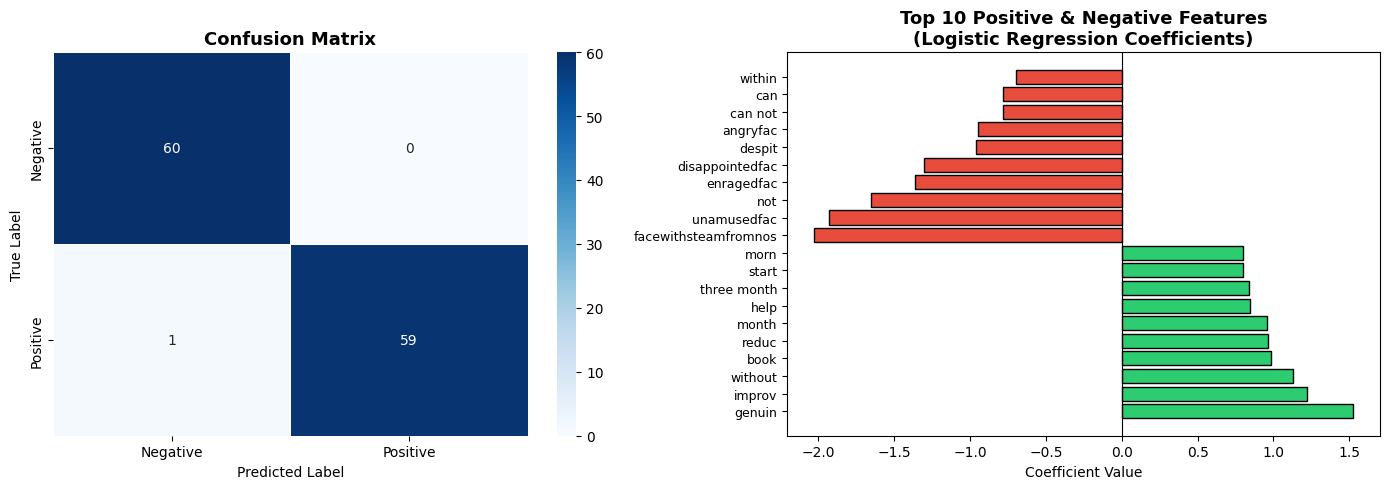

In [38]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ──────────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ── Top 20 Most Influential Features ─────────────────────────────
feature_names = vectorizer.get_feature_names_out()
coefs         = model.coef_[0]

top_pos_idx = coefs.argsort()[-10:][::-1]
top_neg_idx = coefs.argsort()[:10]
top_idx     = np.concatenate([top_pos_idx, top_neg_idx])

top_features = [feature_names[i] for i in top_idx]
top_coefs    = [coefs[i]         for i in top_idx]
colors       = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_coefs]

axes[1].barh(range(len(top_coefs)), top_coefs, color=colors, edgecolor='black')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features, fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 Positive & Negative Features\n(Logistic Regression Coefficients)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

## 11. Predict on New Custom Review

In [39]:
def predict_sentiment(raw_review: str) -> dict:
    """
    End-to-end prediction for a raw review string.
    Returns a dict with the label, confidence, and cleaned text.
    """
    cleaned   = preprocess(raw_review)
    vectorized = vectorizer.transform([cleaned])
    label      = model.predict(vectorized)[0]
    proba      = model.predict_proba(vectorized)[0]
    confidence = proba[label]

    return {
        'raw_review'   : raw_review,
        'cleaned_text' : cleaned,
        'sentiment'    : 'Positive ✅' if label == 1 else 'Negative ❌',
        'confidence'   : f'{confidence * 100:.1f}%',
        'prob_positive': f'{proba[1] * 100:.1f}%',
        'prob_negative': f'{proba[0] * 100:.1f}%',
    }


# ── Test on three diverse examples ───────────────────────────────
test_reviews = [
    # Positive with noise
    "This wireless keyboard is fantastic 🎉 at $49.99 it is well worth it. "
    "Check https://amzn.to/3xYqP1r for the deal. @TechReviewDaily agrees!",

    # Negative with noise
    "Terrible build quality 😡 broke after two weeks and costs $129.99. "
    "I emailed support@brandname.com but never got a reply. Waste of money.",

    # Nuanced / borderline
    "The camera is decent for the $74.99 price 😐 but the battery drains "
    "really fast and the app crashes sometimes. Not sure I'd buy again.",
]

for review in test_reviews:
    result = predict_sentiment(review)
    print('─' * 60)
    print(f"INPUT    : {result['raw_review'][:80]}...")
    print(f"CLEANED  : {result['cleaned_text']}")
    print(f"RESULT   : {result['sentiment']}  |  Confidence: {result['confidence']}")
    print(f"PROBA    : Positive={result['prob_positive']}  Negative={result['prob_negative']}")
print('─' * 60)

────────────────────────────────────────────────────────────
INPUT    : This wireless keyboard is fantastic 🎉 at $49.99 it is well worth it. Check https...
CLEANED  : wireless keyboard fantast partypopp well worth check deal agre
RESULT   : Positive ✅  |  Confidence: 52.8%
PROBA    : Positive=52.8%  Negative=47.2%
────────────────────────────────────────────────────────────
INPUT    : Terrible build quality 😡 broke after two weeks and costs $129.99. I emailed supp...
CLEANED  : terribl build qualiti enragedfac broke two week cost email never got repli wast money
RESULT   : Negative ❌  |  Confidence: 67.2%
PROBA    : Positive=32.8%  Negative=67.2%
────────────────────────────────────────────────────────────
INPUT    : The camera is decent for the $74.99 price 😐 but the battery drains really fast a...
CLEANED  : camera decent price neutralfac batteri drain realli fast app crash sometim not sure id buy
RESULT   : Negative ❌  |  Confidence: 61.8%
PROBA    : Positive=38.2%  Negative=61.8%
─

## 12. Pipeline Summary

In [40]:
print('╔══════════════════════════════════════════════════════════╗')
print('║          AMAZON SENTIMENT ANALYSIS — SUMMARY            ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Dataset size          : {len(data)} reviews (balanced 50/50)      ║')
print(f'║  Train / Test split    : 80% / 20%  (stratified)        ║')
print(f'║  TF-IDF features       : {X_train_tfidf.shape[1]} (unigrams + bigrams)  ║')
print(f'║  Test Accuracy         : {acc*100:.2f}%                         ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  PREPROCESSING STEPS                                     ║')
print('║  1. clean_tweet_1  → emoji demojize, strip URL/email/    ║')
print('║                       handle/price, remove punct+digits  ║')
print('║  2. clean_tweet_2  → stopword removal (negations kept)   ║')
print('║  3. tokenization   → TreebankWordTokenizer               ║')
print('║  4. stem_tokens    → Porter Stemmer                      ║')
print('║  5. preprocess()   → master pipeline (steps 1–4)         ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║          AMAZON SENTIMENT ANALYSIS — SUMMARY            ║
╠══════════════════════════════════════════════════════════╣
║  Dataset size          : 600 reviews (balanced 50/50)      ║
║  Train / Test split    : 80% / 20%  (stratified)        ║
║  TF-IDF features       : 3000 (unigrams + bigrams)  ║
║  Test Accuracy         : 99.17%                         ║
╠══════════════════════════════════════════════════════════╣
║  PREPROCESSING STEPS                                     ║
║  1. clean_tweet_1  → emoji demojize, strip URL/email/    ║
║                       handle/price, remove punct+digits  ║
║  2. clean_tweet_2  → stopword removal (negations kept)   ║
║  3. tokenization   → TreebankWordTokenizer               ║
║  4. stem_tokens    → Porter Stemmer                      ║
║  5. preprocess()   → master pipeline (steps 1–4)         ║
╚══════════════════════════════════════════════════════════╝
